In [1]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
from torchinfo import summary
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from PIL import Image
from scipy import signal
import seaborn as sns
import pandas as pd
import numpy as np
import warnings
import math
import os
warnings.filterwarnings('ignore')

C:\Users\abhin\AppData\Roaming\Python\Python312\site-packages\threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


In [2]:
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 150)

In [3]:
while not os.path.isdir(os.path.join(os.getcwd(), 'data')):
    os.chdir("../") # set cwd to root dir

In [4]:
num_participants = 18
ignore_participant_ids = [4,7,16]

In [5]:
class DUO_GAIT(Dataset):
    def __init__(self, allowed_sensors, participant_id, remove_outliers=True, transform=None, target_transform=None):
        self.participant_id = participant_id
        self.allowed_sensors = allowed_sensors

        lf_control_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_control/sub_{participant_id:02}/left_foot_core_params.csv")
        lf_control_df.rename({ "timestamps": "start_times" }, axis=1, inplace=True)
        lf_control_df['is_fatigue'] = 0
        lf_control_df['is_right_foot'] = 0
        lf_control_df['Participant'] = participant_id

        self.create_start_end_samples_strides(lf_control_df, is_control=1)

        rf_control_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_control/sub_{participant_id:02}/right_foot_core_params.csv")
        rf_control_df.rename({ "timestamps": "start_times" }, axis=1, inplace=True)
        rf_control_df['is_fatigue'] = 0
        rf_control_df['is_right_foot'] = 1
        rf_control_df['Participant'] = participant_id

        self.create_start_end_samples_strides(rf_control_df, is_control=1)

        lf_fatigue_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_fatigue/sub_{participant_id:02}/left_foot_core_params.csv")
        lf_fatigue_df.rename({ "timestamps": "start_times" }, axis=1, inplace=True)
        lf_fatigue_df['is_fatigue'] = 1
        lf_fatigue_df['is_right_foot'] = 0
        lf_fatigue_df['Participant'] = participant_id

        self.create_start_end_samples_strides(lf_fatigue_df, is_control=0)

        rf_fatigue_df = pd.read_csv(f"data/DUO-GAIT/processed/OG_st_fatigue/sub_{participant_id:02}/right_foot_core_params.csv")
        rf_fatigue_df.rename({ "timestamps": "start_times" }, axis=1, inplace=True)
        rf_fatigue_df['is_fatigue'] = 1
        rf_fatigue_df['is_right_foot'] = 1
        rf_fatigue_df['Participant'] = participant_id

        self.create_start_end_samples_strides(rf_fatigue_df, is_control=0)

        self.foot_strides_df = pd.concat([lf_control_df, rf_control_df, lf_fatigue_df, rf_fatigue_df], axis=0)

        if remove_outliers:
            self.foot_strides_df = self.foot_strides_df[self.foot_strides_df['is_outlier']==False].reset_index(drop=True)

        self.transform = transform
        self.target_transform = target_transform

    def create_start_end_samples_strides(self, df, is_control):
        df['start_samples'] = df['ic_samples'].shift(1)
        target_time = df.loc[0, 'start_times']
        
        protocol = "control" if is_control else "fatigue"

        fatigue_df = pd.read_csv(f"data/DUO-GAIT/interim/OG_st_{protocol}/sub_{self.participant_id:02}/LF.csv")
        fatigue_df.rename({ "timestamp": "Time (secs)", "Unnamed: 0": "Sample" }, axis=1, inplace=True)
        fatigue_df['Delta (secs)'] = fatigue_df['Time (secs)'] - fatigue_df['Time (secs)'].min() # delta time

        ts_eq_check = fatigue_df['Delta (secs)'].apply(lambda x: math.isclose(x, target_time, rel_tol=1e-5))
        start_sample = fatigue_df[ts_eq_check]['Sample'].item() - fatigue_df['Sample'].min()

        df.loc[0, 'start_samples'] = start_sample
        df['start_samples'] = df['start_samples'] + fatigue_df['Sample'].min()
        df['end_samples'] = df['ic_samples'] + fatigue_df['Sample'].min() - 1 # make it inclusive for ending samples too

        df['start_samples'] = df['start_samples'].astype(np.int64)
        df['end_samples'] = df['end_samples'].astype(np.int64)

    def __len__(self):
        return len(self.foot_strides_df)

In [6]:
stride_lengths = pd.DataFrame()
num_strides = 0

for pid in range(1, num_participants+1):
    if pid in ignore_participant_ids:
        continue
    
    dataset = DUO_GAIT(allowed_sensors=["LL"], participant_id=pid)
    for sample in range(0, len(dataset)):
        num_strides += len(dataset)
        num_samples = (dataset.foot_strides_df['end_samples'] - dataset.foot_strides_df['start_samples'] + 1)

        stride_df = pd.DataFrame({'num_samples': num_samples})
        if num_samples.min() == 0:
            print("0 found at sample", sample, "with participant", pid)

        stride_lengths = pd.concat([stride_lengths, stride_df], axis=0)

<Axes: xlabel='num_samples', ylabel='Count'>

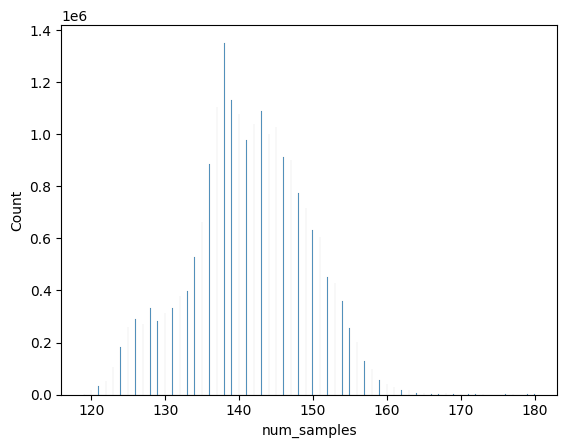

In [7]:
sns.histplot(stride_lengths, x='num_samples')

In [8]:
stride_lengths.min()

num_samples    119
dtype: int64

In [9]:
stride_lengths.max()

num_samples    180
dtype: int64